# Customer Churn Prediction using Explainable AI
## Notebook 07 — SHAP Explainability

## Project Overview

This project develops a machine learning system to predict customer churn and identify customers who are at risk of leaving the company.

In the previous phase, multiple classification models were evaluated using Accuracy, Precision, Recall, F1-Score, ROC-AUC, confusion matrices, and false-negative analysis.

Decision Tree was selected as the final model because it achieved the highest Recall and F1-Score and produced the lowest number of False Negatives.

This notebook focuses on Explainable AI using SHAP (SHapley Additive exPlanations) to understand which features influence the model's churn predictions.

The goal is not only to predict churn, but also to understand why a customer is predicted to churn.

## Objectives

The main objectives of this notebook are:

- Explain the predictions of the final Decision Tree model.
- Identify the most important features influencing churn predictions.
- Analyze the overall factors associated with model predictions.
- Explain the prediction of an individual high-risk customer.
- Identify features that increase or decrease an individual customer's churn risk.
- Generate visual explanations that can support business decision-making.

## Importing Required Libraries:

In [ ]:
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


## Load Final Model

The final Decision Tree pipeline selected during model evaluation is loaded for explainability analysis.

The saved pipeline contains the preprocessing steps and the trained Decision Tree model.

In [ ]:
Final_Model = joblib.load('/content/final_churn_model.pkl')
print("Final_Model loaded sucessfully")

Final_Model loaded sucessfully


## Loading Evaluation Data:

We already created Evaluation_data.pkl in the previous phases.

In [ ]:
evaluation_data= joblib.load("/content/Evaluation_data.pkl")
print("Evaluation data loaded successfully")
print(evaluation_data.keys())

Evaluation data loaded successfully
dict_keys(['y_test', 'x_test', 'Predictions', 'Probabilities'])


## Get Test Data

We only need the test data for SHAP analysis.

In [ ]:
x_test = evaluation_data['x_test']
y_test = evaluation_data['y_test']
print(f"x_test shape: {x_test.shape}")
print(f"y_test shape: {y_test.shape}")

x_test shape: (1409, 25)
y_test shape: (1409,)


## Extract Preprocessor and Model

This is an important step because your saved object is a Pipeline.
- Preprocessor
- Final Model

We need to separate these internally so SHAP can explain the actual Decision Tree.

In [ ]:
Preprocessor  = Final_Model.steps[0][1]
Model = Final_Model.steps[-1][1]
print("Preprocessor",type(Preprocessor))
print("Model",type(Model))

Preprocessor <class 'sklearn.compose._column_transformer.ColumnTransformer'>
Model <class 'sklearn.tree._classes.DecisionTreeClassifier'>


## Transform Test Data

The Decision Tree itself works on the processed numerical representation, not the original categorical strings.

So we apply the same preprocessor that was already fitted during training.

In [ ]:
print(x_test.dtypes)

Gender                       object
Senior Citizen               object
Partner                      object
Dependents                   object
Tenure Months                 int64
Phone Service                object
Multiple Lines               object
Internet Service             object
Online Security              object
Online Backup                object
Device Protection            object
Tech Support                 object
Streaming TV                 object
Streaming Movies             object
Contract                     object
Paperless Billing            object
Payment Method               object
Monthly Charges             float64
Total Charges               float64
CLTV                          int64
Total Aditional Services      int64
Total Streaming Services      int64
Total Security Services       int64
Tenure Group                 object
Has Multiple Services         int64
dtype: object


In [ ]:
x_test_processed = Preprocessor.transform(x_test)
#print(x_test_processed.shape)
print(type(x_test_processed))

<class 'numpy.ndarray'>


We can see here, the shape of x_test_processed is not same as x_test data. Actually data after perfoming oneHotEncoding, changes in shape.

### Check the Transformed Data Format

The preprocessor has already converted the test data into a dense NumPy array.

Therefore, no additional conversion to dense format is required before applying SHAP.

## Getting Feature Names:
This is very important.

We don't want SHAP to show:

- `Feature 1`
- `Feature 2`
- `Feature 3`

We want actual feature names.

In [ ]:
feature_names   = Preprocessor.get_feature_names_out()
print(feature_names)
#print(len(feature_names))

['numeric__Tenure Months' 'numeric__Monthly Charges'
 'numeric__Total Charges' 'numeric__CLTV'
 'numeric__Total Aditional Services' 'numeric__Total Streaming Services'
 'numeric__Total Security Services' 'numeric__Has Multiple Services'
 'categorical__Gender_Female' 'categorical__Gender_Male'
 'categorical__Senior Citizen_No' 'categorical__Senior Citizen_Yes'
 'categorical__Partner_No' 'categorical__Partner_Yes'
 'categorical__Dependents_No' 'categorical__Dependents_Yes'
 'categorical__Phone Service_No' 'categorical__Phone Service_Yes'
 'categorical__Multiple Lines_No'
 'categorical__Multiple Lines_No phone service'
 'categorical__Multiple Lines_Yes' 'categorical__Internet Service_DSL'
 'categorical__Internet Service_Fiber optic'
 'categorical__Internet Service_No' 'categorical__Online Security_No'
 'categorical__Online Security_No internet service'
 'categorical__Online Security_Yes' 'categorical__Online Backup_No'
 'categorical__Online Backup_No internet service'
 'categorical__Onlin

### Create SHAP Explainer

SHAP is used to explain how the trained Decision Tree makes its predictions.

TreeExplainer is used because our final model is a Decision Tree.

In [ ]:
explainer = shap.TreeExplainer(model = Model)
print(explainer)

### Calculate SHAP Values

SHAP values show how much each feature contributes to the model's predictions.

For each customer, SHAP calculates the contribution of the 55 features toward the prediction.

In [ ]:
shap_values = explainer.shap_values(x_test_processed)
print(shap_values)
print(shap_values.shape)

[[[ 0.10754262 -0.10754262]
  [-0.05181962  0.05181962]
  [ 0.0037579  -0.0037579 ]
  ...
  [ 0.          0.        ]
  [ 0.          0.        ]
  [ 0.          0.        ]]

 [[-0.08275786  0.08275786]
  [-0.01121974  0.01121974]
  [ 0.02523957 -0.02523957]
  ...
  [ 0.          0.        ]
  [ 0.          0.        ]
  [ 0.          0.        ]]

 [[ 0.02698699 -0.02698699]
  [ 0.02964342 -0.02964342]
  [ 0.00281053 -0.00281053]
  ...
  [ 0.          0.        ]
  [ 0.          0.        ]
  [ 0.          0.        ]]

 ...

 [[-0.01174557  0.01174557]
  [ 0.00967872 -0.00967872]
  [-0.01173742  0.01173742]
  ...
  [ 0.          0.        ]
  [ 0.          0.        ]
  [ 0.          0.        ]]

 [[ 0.02687672 -0.02687672]
  [ 0.03652782 -0.03652782]
  [ 0.00383237 -0.00383237]
  ...
  [ 0.          0.        ]
  [ 0.          0.        ]
  [ 0.          0.        ]]

 [[ 0.02893394 -0.02893394]
  [ 0.00636316 -0.00636316]
  [ 0.00349682 -0.00349682]
  ...
  [ 0.          0.      

### Extract SHAP Values for the Churn Class

SHAP has calculated feature contributions for both Non-Churn and Churn classes.

Since our main objective is to explain customer churn, we will use the SHAP values corresponding to the Churn class (class 1).

In [ ]:
shap_values_churn = shap_values[:,:,1]
print(shap_values_churn.shape)

(1409, 55)


### Calculate Global Feature Importance

Global SHAP feature importance shows which features have the greatest overall influence on the model's churn predictions.

We calculate the mean absolute SHAP value for each feature across all test customers.

**Process:**

1. Calculate SHAP contributions for all 1409 test customers.
2. Take the absolute value of each SHAP contribution.
3. Calculate the mean absolute SHAP value for each feature.
4. Rank features based on their overall importance.

In [ ]:
importance = np.abs(shap_values_churn).mean(axis = 0)
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Mean Absolute SHAP": importance
    }
)
importance_df = importance_df.sort_values(by = "Mean Absolute SHAP", ascending = False)
print(importance_df.head(3))

                                      Feature  Mean Absolute SHAP
42       categorical__Contract_Month-to-month            0.143187
22  categorical__Internet Service_Fiber optic            0.072565
0                      numeric__Tenure Months            0.054916


### Understanding the SHAP Values and Feature Importance

The SHAP analysis is performed in three stages:

1. **`shap_values`**  
   Contains the complete SHAP explanations for all test customers, all features, and both classes (Non-Churn and Churn).  
   Shape: `(1409, 55, 2)`

2. **`shap_values_churn`**  
   Extracts only the SHAP values for the **Churn class (Class 1)** because our main objective is to explain customer churn.  
   Shape: `(1409, 55)`

3. **`importance`**  
   Summarizes the overall importance of each feature across all 1409 customers by calculating the **mean absolute SHAP value**.  
   This produces one overall importance score for each of the 55 features.

**In simple terms:**

`shap_values` → All explanations  
↓  
`shap_values_churn` → Only Churn explanations  
↓  
`importance` → Overall importance of each feature

> **Note:** `shap_values_churn` still contains individual customer-level contributions.  
> `importance` summarizes those contributions across all customers, so it is used for **global feature importance**.

### SHAP Bar Chart

This bar chart ranks the features according to their mean absolute SHAP values across all test customers.

It shows which features have the greatest overall influence on the model's churn predictions.

A higher mean absolute SHAP value indicates greater feature importance.

**Note:** This chart shows the magnitude of feature influence, but not whether a feature increases or decreases churn risk.

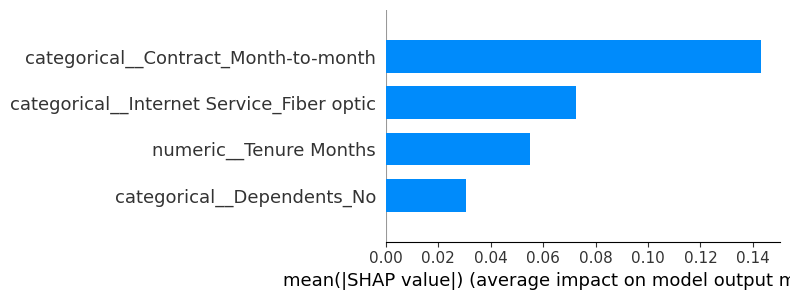

In [ ]:
shap.summary_plot(
    shap_values_churn,
    x_test_processed,
    feature_names = feature_names,
    plot_type = "bar",
    max_display = 4
)

### SHAP Summary Plot

The SHAP summary plot provides a detailed explanation of how the features influence the model's churn predictions.

It shows:

- **Feature importance:** Features are ranked from most to least influential.
- **SHAP value:** Positive values push the prediction toward churn, while negative values push it away from churn.
- **Feature value:** Red represents higher feature values, while blue represents lower feature values.

This plot helps us understand both **which features are important** and **how their values influence the predicted churn risk**.

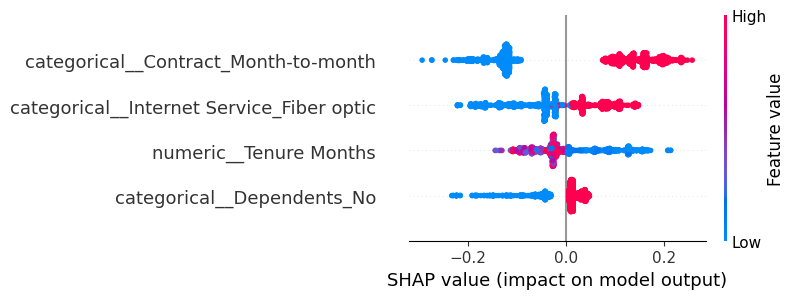

In [ ]:
shap.summary_plot(
    shap_values_churn,
    x_test_processed,
    feature_names = feature_names,
    max_display = 4
)

### Individual Customer SHAP Explanation

SHAP can explain the prediction of an individual customer by showing how each feature contributes to the predicted churn risk.

A high-risk customer is selected to understand which features push the model's prediction toward or away from churn.

In [ ]:
probabilities = evaluation_data["Probabilities"]
dt_proba = probabilities["Decision Tree"]
high_risk_index = np.argmax(dt_proba)
print(f"Customer Index: {high_risk_index}")
print(f"Churn Probabilty: {dt_proba[high_risk_index]}")

Customer Index: 415
Churn Probabilty: 1.0


In [ ]:
customer_shap = shap_values_churn[high_risk_index]
print(customer_shap)

[ 6.46787188e-02 -7.84331502e-03 -8.08468974e-03  3.79077711e-01
  0.00000000e+00  0.00000000e+00 -4.45698526e-05  0.00000000e+00
  0.00000000e+00  0.00000000e+00 -1.77973131e-03  0.00000000e+00
  0.00000000e+00  1.15878961e-03  6.53599528e-03  3.86385942e-03
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00 -1.15220650e-02  0.00000000e+00
 -3.77006425e-03  0.00000000e+00  0.00000000e+00  5.14593748e-03
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  1.03587278e-02  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  2.48026214e-01  0.00000000e+00
  8.36112448e-04  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  4.80091565e-02  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00]


In [ ]:
predictions = evaluation_data["Predictions"]
dt_pred = predictions["Decision Tree"]
print(f"Actual:{y_test[high_risk_index]}\n")
print(f"Predicted:{dt_pred[high_risk_index]}\n")
print(f"Probability:{dt_proba[high_risk_index]}")

Actual:1

Predicted:1

Probability:1.0


### SHAP Waterfall Plot

The SHAP waterfall plot explains the prediction of the selected high-risk customer.

Features with positive SHAP values push the prediction toward churn, while negative SHAP values push it away from churn.

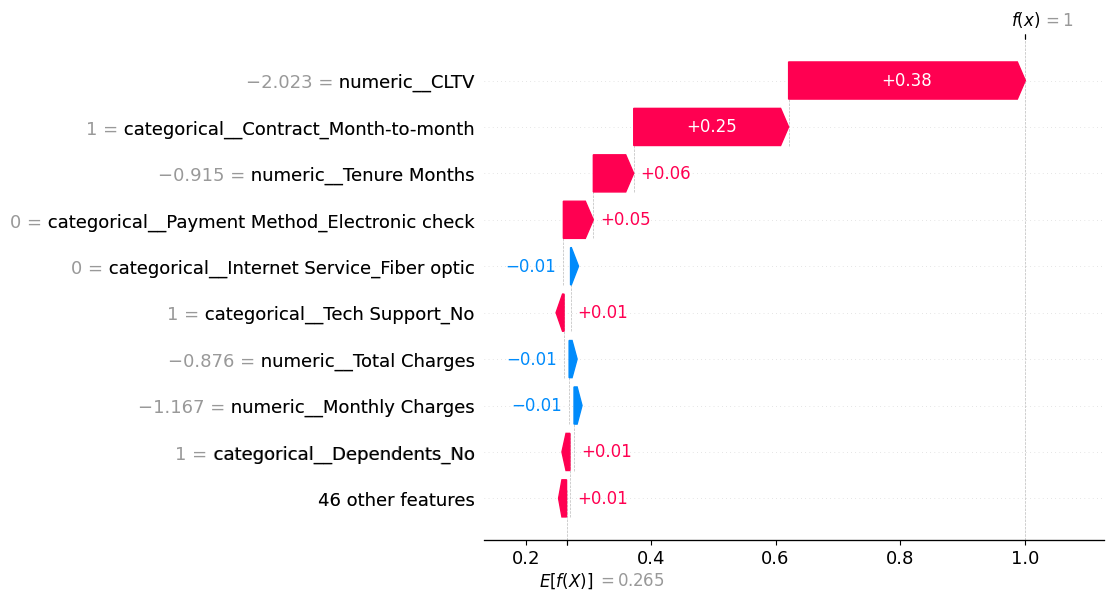

In [ ]:
shap.plots.waterfall(
    shap.Explanation(
        values = customer_shap,
        base_values = explainer.expected_value[1],
        data= x_test_processed[high_risk_index],
        feature_names = feature_names
    )
)

## Saving separated Preprocessor and Model:

In [ ]:
joblib.dump(Preprocessor,"Preprocessor.pkl")
joblib.dump(Model,"Model.pkl")
print("Both saved successfully")

Both saved successfully


### Key SHAP Findings

The SHAP analysis provides both global and individual explanations of the churn prediction model.

**Global Findings:**
- Contract type, particularly month-to-month contracts, is the most influential feature in the model.
- Internet Service, Tenure Months, Dependents, Payment Method, and Monthly Charges are also among the important features.
- The SHAP summary plot shows how different feature values influence the model's churn predictions.

**Individual Customer Finding:**
- The selected high-risk customer received a predicted churn probability of 1.0.
- The strongest factors pushing this customer's prediction toward churn were CLTV, month-to-month contract, tenure, and electronic check payment method.
- Some features provided small contributions away from churn, but their impact was comparatively weak.

### Conclusion

SHAP analysis helped explain the decisions of the churn prediction model at both global and individual levels.

The global analysis identified the features that have the greatest influence on churn predictions, while the individual waterfall plot showed why a specific high-risk customer was predicted to churn.

Overall, the analysis demonstrates that the model is not only capable of predicting customer churn but can also provide interpretable reasons behind its predictions.